In [ ]:
#VIF regrssion 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [2]:
import pandas as pd
df = pd.read_csv("/content/Urban_Property_Value_Regression_c99adb8b4456241e9c0dd40586dcac09.csv")
df.head(10)

,Distance_CBD,School_Quality,Crime_Rate,Median_Income,Green_Cover,Zone_Type,Transport_Access,Income_Log,Crime_Squared,Property_Value_Index
0,11.236204,2.666196,2.617057,141086.53900,57.199588,Rural,Medium,11.857129,6.848986,186781.08750
1,28.521429,5.877109,2.469788,163402.65150,80.543233,Rural,Medium,12.003973,6.099853,113499.90770
2,21.959818,8.856513,9.062546,65084.22178,76.016093,Rural,High,11.083437,82.129736,30292.04797
3,17.959755,7.590024,2.495462,132477.33790,15.389990,Semi-Urban,Medium,11.794167,6.227331,181106.56060
4,4.680559,8.259050,2.719497,122914.27700,14.924947,Rural,High,11.719242,7.395665,326848.98820
5,4.679836,6.929050,7.593983,169909.46780,26.817437,Urban,Low,12.043021,57.668572,326575.47010
6,1.742508,7.230489,4.497398,183095.67090,36.107473,Rural,Medium,12.117764,20.226593,344425.74430
7,25.985284,8.642761,7.767106,22188.21887,40.845558,Urban,High,10.007317,60.327929,11933.96303
8,18.033450,3.247012,0.653662,141323.58540,67.969722,Rural,Medium,11.858807,0.427273,159063.61800
9,21.242177,5.404825,4.875712,29330.44384,5.668043,Rural,Medium,10.286381,23.772567,49548.29812


In [4]:
df.shape

(1000, 10)

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#separate features
X_vif = df.drop('Property_Value_Index', axis=1)

#calculate VIF
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data.sort_values(by='VIF', ascending=False)

,feature,VIF
2,Crime_Rate,62.350055
8,Crime_Squared,35.410990
7,Income_Log,33.815803
3,Median_Income,7.228574
1,School_Quality,5.505234
4,Green_Cover,4.000067
0,Distance_CBD,3.849812
6,Transport_Access,2.630360
5,Zone_Type,2.578741


In [20]:
x=df.drop(columns=['Property_Value_Index'])
y=df['Property_Value_Index']

In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('knn',KNeighborsRegressor())
])

In [24]:
param_grid = {
  'knn__n_neighbors': list(range(1, 21)),
  'knn__weights': ['uniform', 'distance'],
  'knn__p': [1, 2]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20],
                         'knn__p': [1, 2],
                         'knn__weights': ['uniform', 'distance']},
             scoring='neg_mean_squared_error')

In [26]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2F}")
print(f"R2 Score: {r2:.3f}")
print(f"R-squared: {r2}")

RMSE: 53978.96
R2 Score: 0.849
R-squared: 0.8485630166742397


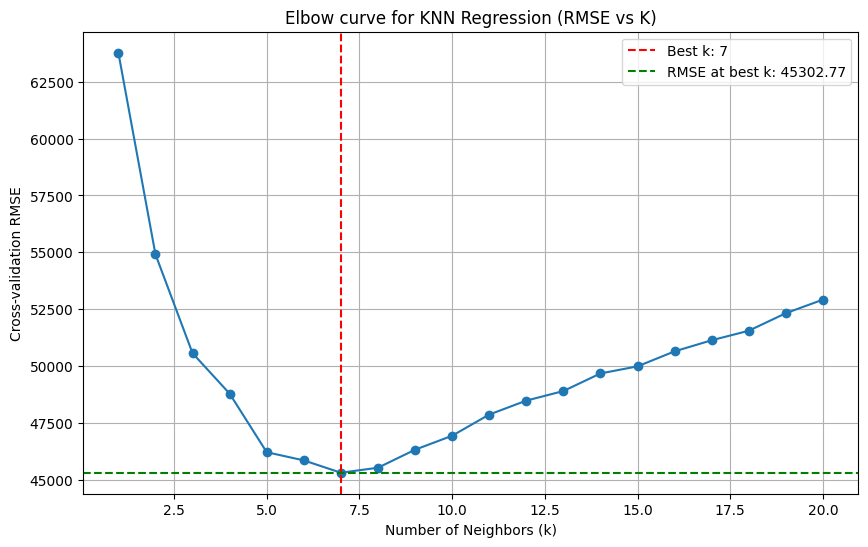

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
rmse_k_values = np.sqrt(-rmse_k_df['mean_test_score'])
n_neighbors_for_plot = rmse_k_df['param_knn__n_neighbors']
rmse_k = pd.Series(rmse_k_values.values, index=n_neighbors_for_plot.values)

# Get the best k from grid.best_params_
best_k = grid.best_params_['knn__n_neighbors']

plt.figure(figsize=(10, 6))
plt.plot(rmse_k.index, rmse_k.values, marker='o')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best k: {best_k}')
plt.axhline(y=rmse_k.loc[best_k], color='g', linestyle='--', label=f'RMSE at best k: {rmse_k.loc[best_k]:.2f}')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-validation RMSE")
plt.title("Elbow curve for KNN Regression (RMSE vs K)")
plt.legend()
plt.grid(True)
plt.show()

#classification

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [31]:
import pandas as pd
df = pd.read_csv("/content/Medical_Risk_Classification_cc82c41bbb6c596fe8a17da8992ed191.csv")
df.head(20)

,Biomarker_A,Biomarker_B,BMI,Age,Smoking_Status,Family_History,BMI_Squared,Age_Normalized,High_Risk
0,1.572821,0.719531,20.921853,76.852031,Non-Smoker,Yes,437.723931,0.960650,1
1,0.421854,1.924399,19.006796,41.350755,Current,No,361.258302,0.516884,1
2,3.425030,5.205850,19.791748,34.992573,Non-Smoker,Yes,391.713285,0.437407,1
3,3.538766,1.395408,21.139071,56.973044,Current,Yes,446.860330,0.712163,1
4,1.799962,3.646175,23.798603,49.932369,Non-Smoker,No,566.373523,0.624155,0
5,0.383617,2.416027,27.240174,79.351134,Former,Yes,742.027079,0.991889,1
6,2.131489,1.247062,30.098595,47.741707,Non-Smoker,Yes,905.925421,0.596771,1
7,2.211677,4.880441,21.585765,24.459893,Non-Smoker,Yes,465.945238,0.305749,1
8,3.343354,4.456988,29.432881,78.642144,Former,No,866.294476,0.983027,1
9,1.577082,3.969546,29.972404,70.615217,Former,No,898.345018,0.882690,1


In [32]:
df.shape

(1000, 9)

In [33]:
df['Family_History'].value_counts()

,count
Family_History,
Yes,513
No,487


In [35]:
x = df.drop('High_Risk', axis=1)
y = df['High_Risk']

x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42, stratify=y
)

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

pipeline = Pipeline([
  ('scaler', StandardScaler()),
  ('knn', KNeighborsClassifier())
])

In [45]:
from sklearn.metrics import accuracy_score

best_model = grid.best_estimator_
y_pred = best_model.predict(x_test_encoded) # Use x_test_encoded for prediction
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.91


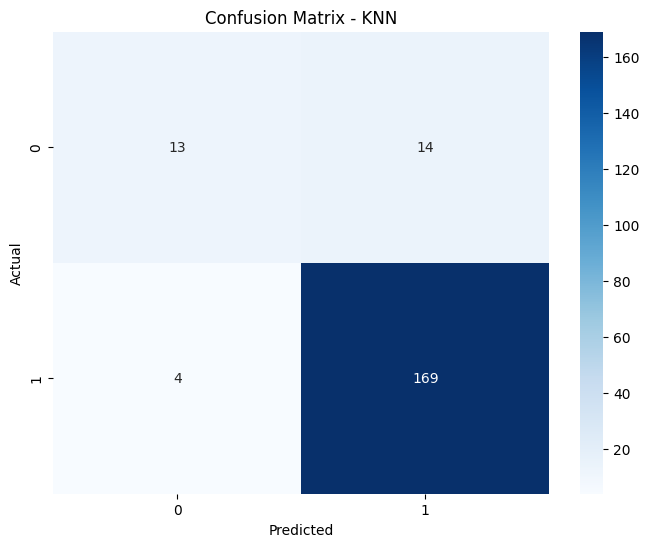

In [46]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN')
plt.show()

In [47]:
#classification reoprt

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.48      0.59        27
           1       0.92      0.98      0.95       173

    accuracy                           0.91       200
   macro avg       0.84      0.73      0.77       200
weighted avg       0.90      0.91      0.90       200



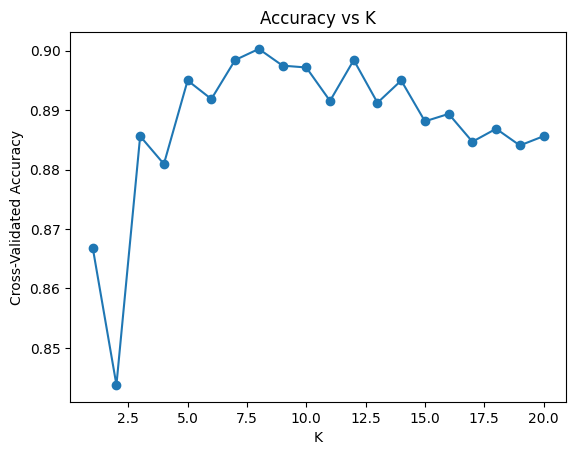

In [50]:
cv_result = pd.DataFrame(grid.cv_results_)
accurcy_k = cv_result.groupby('param_knn__n_neighbors')['mean_test_score'].mean()
best_k = accurcy_k.idxmax()

plt.figure()
plt.plot(accurcy_k.index, accurcy_k.values, marker='o')
plt.xlabel('K')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Accuracy vs K')
plt.show()